<a href="https://colab.research.google.com/github/princedanson/Intermidiate_1/blob/main/tutorials/contact_5/question_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import (StandardScaler, OneHotEncoder,
                                PowerTransformer,OrdinalEncoder,)
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,log_loss)
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
import kagglehub
import os

In [27]:

path = kagglehub.dataset_download("ibrahimelsayed182/titanic-dataset")
files = os.listdir(path)
for file in files:
    if file.endswith(".csv"):
        path = os.path.join(path, file)
        break
df = pd.read_csv(path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.


In [28]:
df

,sex,age,sibsp,parch,fare,embarked,class,who,alone,survived
0,male,22.0,1,0,7.2500,S,Third,man,False,0
1,female,38.0,1,0,71.2833,C,First,woman,False,1
2,female,26.0,0,0,7.9250,S,Third,woman,True,1
3,female,35.0,1,0,53.1000,S,First,woman,False,1
4,male,35.0,0,0,8.0500,S,Third,man,True,0
...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,0,0,13.0000,S,Second,man,True,0
887,female,19.0,0,0,30.0000,S,First,woman,True,1
888,female,NaN,1,2,23.4500,S,Third,woman,False,0
889,male,26.0,0,0,30.0000,C,First,man,True,1


In [29]:
x = df.drop("survived", axis=1)
y = df["survived"]

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [31]:
nominal_category_columns = ['sex','embarked','who','alone']
ordinal_category_columns = ['class']
numerical_category_columns = ['age','sibsp','parch','fare']

In [32]:

numerical_pipeline =  Pipeline([
    ('Power_transform',PowerTransformer(method='yeo-johnson')),
    ('Scaler',StandardScaler())
])

nominal_pipeline = Pipeline([
    ('One_hot_encoder',OneHotEncoder(handle_unknown='ignore'))
])

ordinal_pipeline = Pipeline([
    ('Ordinal_encoder',OrdinalEncoder())
])

In [42]:
Colums_pipeline = ColumnTransformer([
    ('numerical_pipeline',numerical_pipeline,numerical_category_columns),
    ('nominal_pipeline',nominal_pipeline,nominal_category_columns),
    ('ordinal_pipeline',ordinal_pipeline,ordinal_category_columns),
])

In [50]:

pipeline = Pipeline([
    ('Colums_pipelin',Colums_pipeline),
    ('Simple_imputer',SimpleImputer(strategy='mean')),
    ('Logistic_regression',LogisticRegression(class_weight='balanced'))
])

In [51]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('Colums_pipelin',
                 ColumnTransformer(transformers=[('numerical_pipeline',
                                                  Pipeline(steps=[('Power_transform',
                                                                   PowerTransformer()),
                                                                  ('Scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'sibsp', 'parch',
                                                   'fare']),
                                                 ('nominal_pipeline',
                                                  Pipeline(steps=[('One_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked', 'who',
                                                   'alone']),
                                                 ('ordinal_pipeline',
                                                  Pipeline(steps=[('Ordinal_encoder',
                                                                   OrdinalEncoder())]),
                                                  ['class'])])),
                ('Simple_imputer', SimpleImputer()),
                ('Logistic_regression',
                 LogisticRegression(class_weight='balanced'))])

In [52]:
pred = pipeline.predict(x_test)

In [57]:
cm = confusion_matrix(y_test,pred)
log_loss(y_test,pred)

7.651725300482971

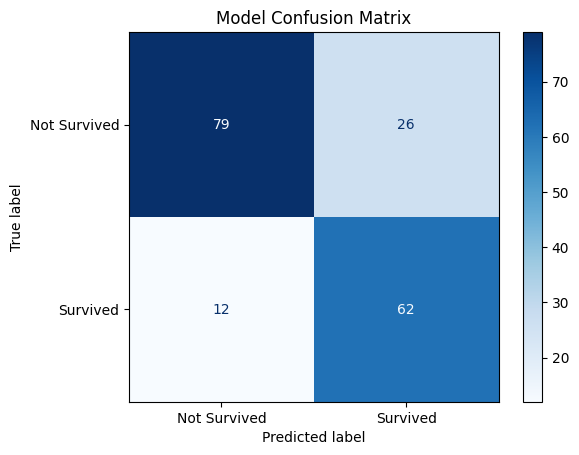

In [58]:

dis = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ['Not Survived','Survived'])
dis.plot(cmap=plt.cm.Blues)
plt.title("Model Confusion Matrix")
plt.show()